In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# display settings
pd.set_option('display.max_columns', None)

In [23]:
df = pd.read_csv("Dataset_used.csv")

In [24]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [25]:
df.tail()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
475,F,Jordan,Jordan,MiddleSchool,G-08,A,Chemistry,S,Father,5,4,5,8,No,Bad,Above-7,L
476,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,F,Father,50,77,14,28,No,Bad,Under-7,M
477,F,Jordan,Jordan,MiddleSchool,G-08,A,Geology,S,Father,55,74,25,29,No,Bad,Under-7,M
478,F,Jordan,Jordan,MiddleSchool,G-08,A,History,F,Father,30,17,14,57,No,Bad,Above-7,L
479,F,Jordan,Jordan,MiddleSchool,G-08,A,History,S,Father,35,14,23,62,No,Bad,Above-7,L


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [27]:
df.shape

(480, 17)

In [28]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [29]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [30]:
df.describe(include='object')

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
count,480,480,480,480,480,480,480,480,480,480,480,480,480
unique,2,14,14,3,10,3,12,2,2,2,2,2,3
top,M,KW,KuwaIT,MiddleSchool,G-02,A,IT,F,Father,Yes,Good,Under-7,M
freq,305,179,180,248,147,283,95,245,283,270,292,289,211


Creating Churn column

In [31]:
df['Churn'] = np.where(
    (df['Class'] == 'L') | (df['StudentAbsenceDays'] == 'Above-7'),
    1,
    0
)

Verifying Churn distribution

In [32]:
df['Churn'].value_counts()

,count
Churn,
0,278
1,202


In [33]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0,57.916667
1,42.083333


In [34]:
df.drop(columns=['Class'], inplace=True)

In [35]:
df.drop(columns=['SectionID', 'PlaceofBirth'], inplace=True)

Encoding binary categorical columns

In [38]:
binary_cols = [
    'ParentAnsweringSurvey'
]

df[binary_cols] = df[binary_cols].replace({'Yes': 1, 'No': 0})


In [39]:
df['ParentschoolSatisfaction'].unique()

array(['Good', 'Bad'], dtype=object)

In [40]:
df['ParentschoolSatisfaction'] = df['ParentschoolSatisfaction'].map({
    'Good': 1,
    'Bad': 0
})

In [41]:
df.head()

,gender,NationalITy,StageID,GradeID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Churn
0,M,KW,lowerlevel,G-04,IT,F,Father,15,16,2,20,1,1,Under-7,0
1,M,KW,lowerlevel,G-04,IT,F,Father,20,20,3,25,1,1,Under-7,0
2,M,KW,lowerlevel,G-04,IT,F,Father,10,7,0,30,0,0,Above-7,1
3,M,KW,lowerlevel,G-04,IT,F,Father,30,25,5,35,0,0,Above-7,1
4,M,KW,lowerlevel,G-04,IT,F,Father,40,50,12,50,0,0,Above-7,1


Churn Distribution visualization

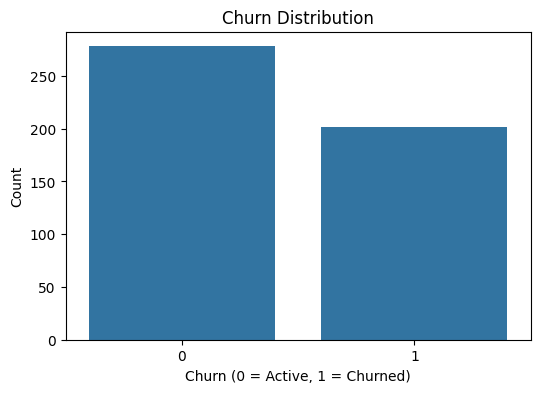

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Active, 1 = Churned)")
plt.ylabel("Count")
plt.show()


In [43]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
0,57.916667
1,42.083333


Engagement vs Churned

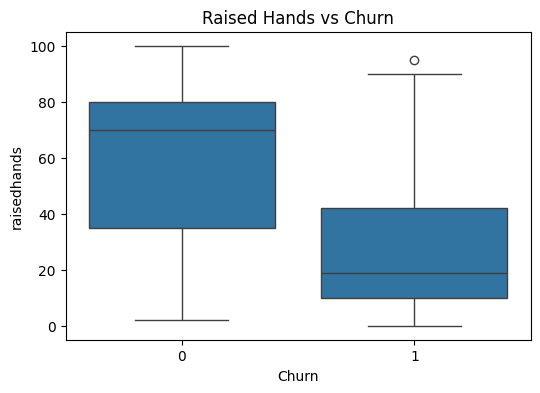

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='raisedhands', data=df)
plt.title("Raised Hands vs Churn")
plt.show()

Visited Resources

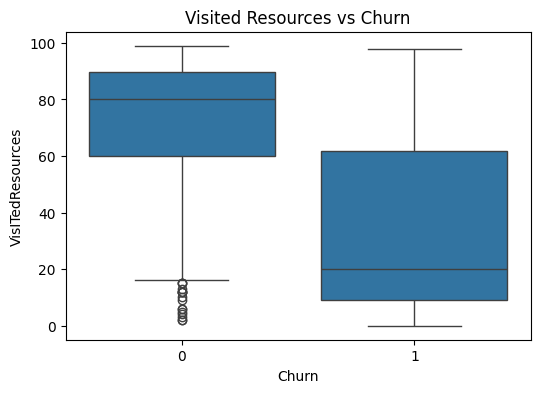

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='VisITedResources', data=df)
plt.title("Visited Resources vs Churn")
plt.show()


Announcements View

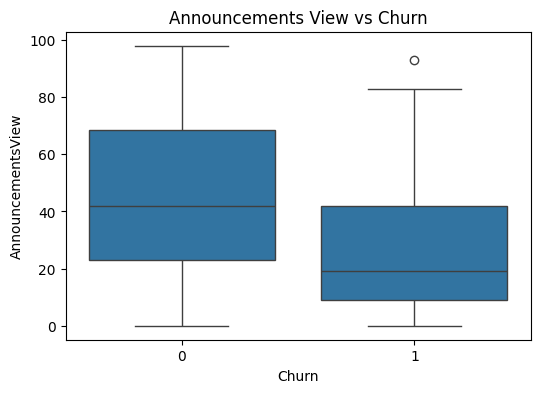

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='AnnouncementsView', data=df)
plt.title("Announcements View vs Churn")
plt.show()

Discussion Participation vs Churned

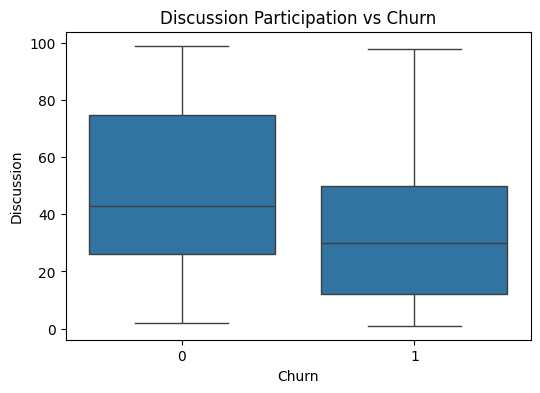

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Discussion', data=df)
plt.title("Discussion Participation vs Churn")
plt.show()


Absence Days vs Churn

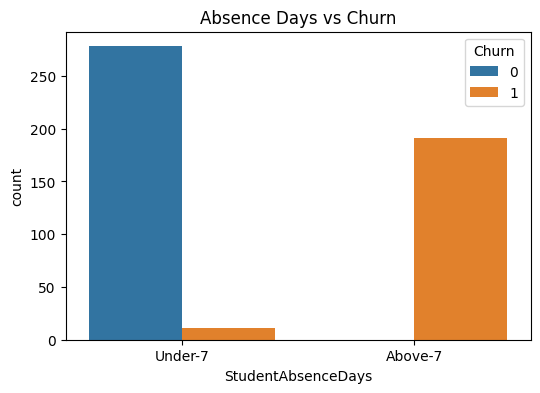

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='StudentAbsenceDays', hue='Churn', data=df)
plt.title("Absence Days vs Churn")
plt.show()


Parent Satisfaction vs Churn

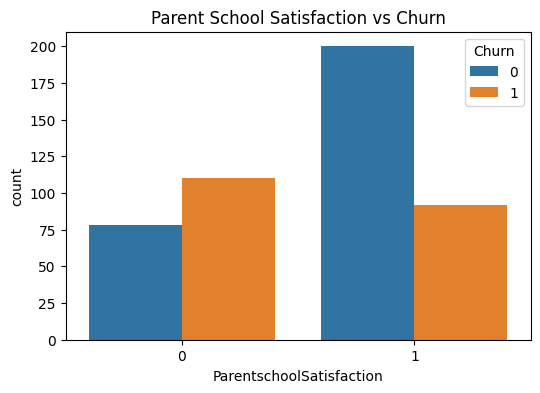

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x='ParentschoolSatisfaction', hue='Churn', data=df)
plt.title("Parent School Satisfaction vs Churn")
plt.show()


Gender vs Churn

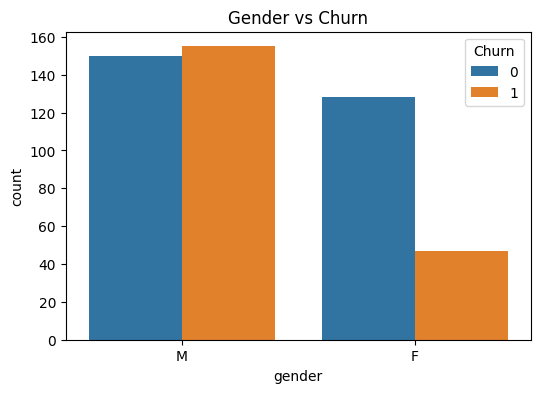

In [50]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()


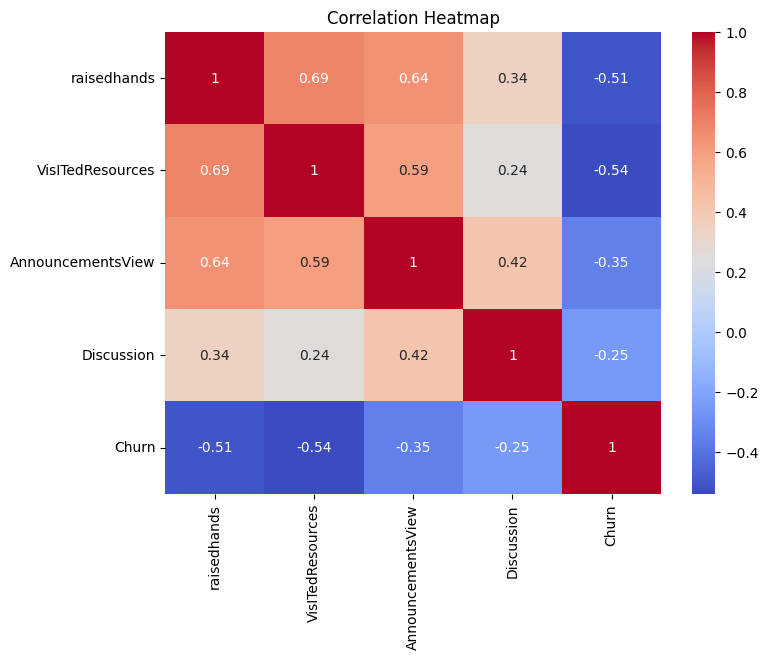

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['raisedhands', 'VisITedResources',
                'AnnouncementsView', 'Discussion', 'Churn']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [52]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [53]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)


Categorical Columns: Index(['gender', 'NationalITy', 'StageID', 'GradeID', 'Topic', 'Semester',
       'Relation', 'StudentAbsenceDays'],
      dtype='object')
Numerical Columns: Index(['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction'],
      dtype='object')


Encoding Categorical Values

In [54]:
from sklearn.preprocessing import OneHotEncoder

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [55]:
X.shape

(480, 45)

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


In [58]:
X_train.head()

,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,gender_M,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,NationalITy_Morocco,NationalITy_Palestine,NationalITy_SaudiArabia,NationalITy_Syria,NationalITy_Tunis,NationalITy_USA,NationalITy_lebanon,NationalITy_venzuela,StageID_MiddleSchool,StageID_lowerlevel,GradeID_G-04,GradeID_G-05,GradeID_G-06,GradeID_G-07,GradeID_G-08,GradeID_G-09,GradeID_G-10,GradeID_G-11,GradeID_G-12,Topic_Biology,Topic_Chemistry,Topic_English,Topic_French,Topic_Geology,Topic_History,Topic_IT,Topic_Math,Topic_Quran,Topic_Science,Topic_Spanish,Semester_S,Relation_Mum,StudentAbsenceDays_Under-7
355,-0.353985,1.271622,0.146193,-0.718626,0.896001,0.809427,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,True
181,0.135207,0.223248,-0.905225,-0.358187,-1.116071,-1.235442,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
214,-0.941015,-0.136195,-1.318282,-1.403461,-1.116071,-1.235442,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
8,-1.104079,-1.004848,-0.792573,0.254560,0.896001,0.809427,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
459,1.113591,1.061947,1.610668,1.444010,0.896001,0.809427,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True


In [59]:
X_train.shape, X_test.shape

((384, 45), (96, 45))

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [72]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

Training the model

In [73]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

Making Predictions

In [74]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

MODEL EVALUATION

In [75]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9791666666666666


In [76]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98        56
           1       0.97      0.97      0.97        40

    accuracy                           0.98        96
   macro avg       0.98      0.98      0.98        96
weighted avg       0.98      0.98      0.98        96



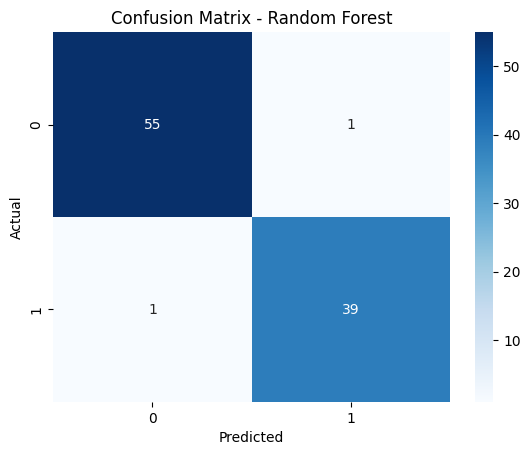

In [77]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [78]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.996875


In [79]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
44,StudentAbsenceDays_Under-7,0.465146
1,VisITedResources,0.136959
0,raisedhands,0.104810
3,Discussion,0.059932
2,AnnouncementsView,0.052260
4,ParentAnsweringSurvey,0.021917
5,ParentschoolSatisfaction,0.016800
43,Relation_Mum,0.016372
6,gender_M,0.014998
10,NationalITy_KW,0.008122


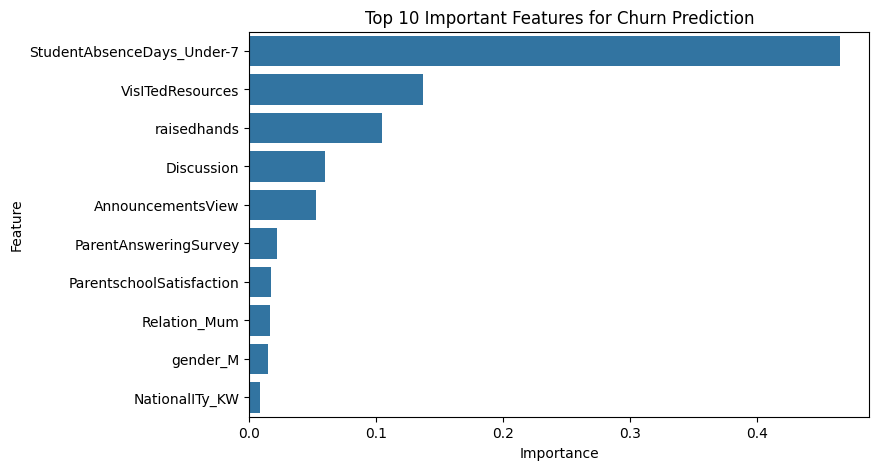

In [80]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features for Churn Prediction")
plt.show()

Hyperparameter Tuning

In [81]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [8, 10, 12], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall')

In [82]:
grid_search.best_params_

{'max_depth': 8,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 100}

In [90]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

In [91]:
best_rf = rf_model.fit(X_train, y_train)

In [92]:
y_pred_final = best_rf.predict(X_test)
y_prob_final = best_rf.predict_proba(X_test)[:, 1]


In [93]:
accuracy_score(y_test, y_pred_final)


0.9791666666666666

In [94]:
print(classification_report(y_test, y_pred_final))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98        56
           1       0.97      0.97      0.97        40

    accuracy                           0.98        96
   macro avg       0.98      0.98      0.98        96
weighted avg       0.98      0.98      0.98        96



In [95]:
roc_auc_score(y_test, y_prob_final)


np.float64(0.9977678571428571)

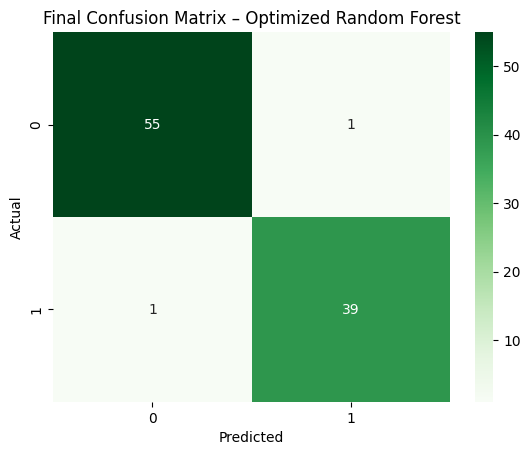

In [96]:
cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix – Optimized Random Forest")
plt.show()
